In [55]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# CAL FIRE dataset
calfire_df = pd.read_csv("fires_with_topography.csv")

# Vegetation dataset
veg_df = pd.read_csv("FMR_202606100304.csv")

In [36]:
print("Cal fire")
print(calfire_df.head())


Cal fire
   incident_name incident_is_final incident_date_last_update  \
0    Bridge Fire                 Y      2018-01-09T13:46:00Z   
1     River Fire                 Y      2022-10-24T11:39:23Z   
2  Fawnskin Fire                 Y      2013-04-22T09:00:00Z   
3      Gold Fire                 Y      2013-05-01T07:00:00Z   
4   Panther Fire                 Y      2022-10-24T11:40:03Z   

  incident_date_created          incident_administrative_unit  \
0  2017-10-31T11:22:00Z       Shasta-Trinity National Forest    
1  2013-02-24T08:16:00Z          CAL FIRE San Bernardino Unit   
2  2013-04-20T17:30:00Z        San Bernardino National Forest   
3  2013-04-30T12:59:00Z  CAL FIRE Madera-Mariposa-Merced Unit   
4  2013-05-01T09:12:00Z                   CAL FIRE Butte Unit   

   incident_administrative_unit_url incident_county  \
0                               NaN          Shasta   
1                               NaN            Inyo   
2                               NaN  San Bernardin

In [39]:
print("Vegetation")
print(veg_df.head())

print("\nCal fire shape")
print(calfire_df.shape)

print("\nVege shape")
print(veg_df.shape)

print("\nCalfire columns")
print(calfire_df.columns)

print("\nVege columns")
print(veg_df.columns)

Vegetation
   STID        DATE FUEL_TYPE FUEL_VARIATION  PERCENT           NAME  GACC  \
0     2  2014-06-03      Duff            NaN      7.0  12 Rd @ 54 Rd  NOCC   
1     2  2014-07-15      Duff            NaN     12.0  12 Rd @ 54 Rd  NOCC   
2     2  2014-08-27      Duff            NaN     16.0  12 Rd @ 54 Rd  NOCC   
3     2  2015-06-04      Duff            NaN    144.0  12 Rd @ 54 Rd  NOCC   
4     2  2015-06-30      Duff            NaN     12.0  12 Rd @ 54 Rd  NOCC   

      GROUP        LAT         LON     ELE  
0  Tahoe NF  39.570556 -120.492778  7600.0  
1  Tahoe NF  39.570556 -120.492778  7600.0  
2  Tahoe NF  39.570556 -120.492778  7600.0  
3  Tahoe NF  39.570556 -120.492778  7600.0  
4  Tahoe NF  39.570556 -120.492778  7600.0  

Cal fire shape
(3405, 30)

Vege shape
(48944, 11)

Calfire columns
Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', '

In [40]:
calfire_df["fire_date"] = (
    pd.to_datetime(
        calfire_df["incident_date_created"],
        errors="coerce",
        utc=True
    )
    .dt.tz_localize(None)
    .dt.normalize()
)

veg_df["veg_date"] = (
    pd.to_datetime(
        veg_df["DATE"],
        errors="coerce"
    )
    .dt.normalize()
)

calfire_df = calfire_df.rename(columns={
    "incident_latitude": "fire_LAT",
    "incident_longitude": "fire_LON"
})

veg_df = veg_df.rename(columns={
    "LAT": "veg_LAT",
    "LON": "veg_LON"
})

calfire_clean = calfire_df.dropna(
    subset=["fire_LAT", "fire_LON", "fire_date"]
).copy()

veg_clean = veg_df.dropna(
    subset=["veg_LAT", "veg_LON", "veg_date"]
).copy()


calfire_clean["fire_LAT"] = pd.to_numeric(calfire_clean["fire_LAT"], errors="coerce")
calfire_clean["fire_LON"] = pd.to_numeric(calfire_clean["fire_LON"], errors="coerce")

veg_clean["veg_LAT"] = pd.to_numeric(veg_clean["veg_LAT"], errors="coerce")
veg_clean["veg_LON"] = pd.to_numeric(veg_clean["veg_LON"], errors="coerce")

calfire_clean = calfire_clean.dropna(subset=["fire_LAT", "fire_LON"])
veg_clean = veg_clean.dropna(subset=["veg_LAT", "veg_LON"])

calfire_clean = calfire_clean.reset_index(drop=True)
calfire_clean["fire_id"] = calfire_clean.index

In [41]:
# Geographical location can hardly be mapped to the exact, therefore I tried finding the nearest data point to map.

veg_locations = (
    veg_clean[["veg_LAT", "veg_LON"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

tree = cKDTree(veg_locations[["veg_LAT", "veg_LON"]].values)

fire_coords = calfire_clean[["fire_LAT", "fire_LON"]].values

distances, indices = tree.query(fire_coords, k=1)

matched_locations = veg_locations.iloc[indices].reset_index(drop=True)

calfire_clean["matched_veg_LAT"] = matched_locations["veg_LAT"]
calfire_clean["matched_veg_LON"] = matched_locations["veg_LON"]
calfire_clean["location_distance_degrees"] = distances


merged = calfire_clean.merge(
    veg_clean,
    left_on=["matched_veg_LAT", "matched_veg_LON"],
    right_on=["veg_LAT", "veg_LON"],
    how="left"
)

merged = merged[merged["veg_date"] <= merged["fire_date"]].copy()
merged["date_gap_days"] = (
    merged["fire_date"] - merged["veg_date"]
).dt.days

result = (
    merged
    .sort_values(["fire_id", "date_gap_days"])
    .groupby("fire_id")
    .head(1)
    .reset_index(drop=True)
)

In [43]:
result[[
    "incident_name",
    "fire_date",
    "fire_LAT",
    "fire_LON",
    "matched_veg_LAT",
    "matched_veg_LON",
    "veg_date",
    "date_gap_days",
    "FUEL_TYPE",
    "PERCENT",
    "GROUP"
]].head()

,incident_name,fire_date,fire_LAT,fire_LON,matched_veg_LAT,matched_veg_LON,veg_date,date_gap_days,FUEL_TYPE,PERCENT,GROUP
0,Bridge Fire,2017-10-31,40.774000,-122.309000,40.870833,-122.389722,2017-10-18,13,Manzanita,73.0,Shasta-Trinity NF
1,Lake Fire,2013-05-17,34.491490,-118.610044,34.510000,-118.594500,2013-05-17,0,Chamise,61.0,LA County
2,Shelton Fire,2013-05-30,38.049930,-120.903250,38.114722,-120.790000,2013-05-23,7,Chamise,82.0,CAL FIRE Toulumne-Calaveras Unit
3,Border Fire,2013-05-22,32.564465,-116.900368,32.666389,-116.700000,2013-05-20,2,Chamise,88.0,SDG&E
4,San Felipe Fire,2013-05-23,33.121110,-116.525790,33.197500,-116.598056,2013-05-23,0,Chamise,90.0,SDG&E


In [44]:
result.to_csv("calfire_topography_vegetation_joined.csv", index=False)

In [45]:
result.head()

,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,FUEL_VARIATION,PERCENT,NAME,GACC,GROUP,veg_LAT,veg_LON,ELE,veg_date,date_gap_days
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,Whiteleaf,73.0,Lakeshore,NOCC,Shasta-Trinity NF,40.870833,-122.389722,1085.0,2017-10-18,13
1,Lake Fire,Y,2013-05-18T19:00:00Z,2013-05-17T13:23:00Z,CAL FIRE/Los Angeles County,NaN,Los Angeles,I-5 Southbound at Lake Hughes Road,712.0,100.0,...,NaN,61.0,"Bitter Canyon, Castaic",SOCC,LA County,34.510000,-118.594500,1745.0,2013-05-17,0
2,Shelton Fire,Y,2013-05-30T13:25:00Z,2013-05-30T11:20:00Z,CAL FIRE Tuolumne-Calaveras Unit,NaN,San Joaquin,off North Shelton Rd in the Linden Peters area,303.0,100.0,...,New Growth,82.0,Valley Springs,SOCC,CAL FIRE Toulumne-Calaveras Unit,38.114722,-120.790000,908.0,2013-05-23,7
3,Border Fire,Y,2013-05-23T08:30:00Z,2013-05-22T16:14:00Z,CAL FIRE San Diego Unit,NaN,San Diego,Off Alta Rd in the Otay Mesa area,100.0,100.0,...,New Growth,88.0,Barrett,SOCC,SDG&E,32.666389,-116.700000,2500.0,2013-05-20,2
4,San Felipe Fire,Y,2022-10-24T11:41:15Z,2013-05-23T12:20:00Z,CAL FIRE San Diego Unit,NaN,San Diego,"San Felipe Road, north of Highway 78, East of ...",2650.0,100.0,...,New Growth,90.0,San Felipe,SOCC,SDG&E,33.197500,-116.598056,3452.0,2013-05-23,0


EDA!

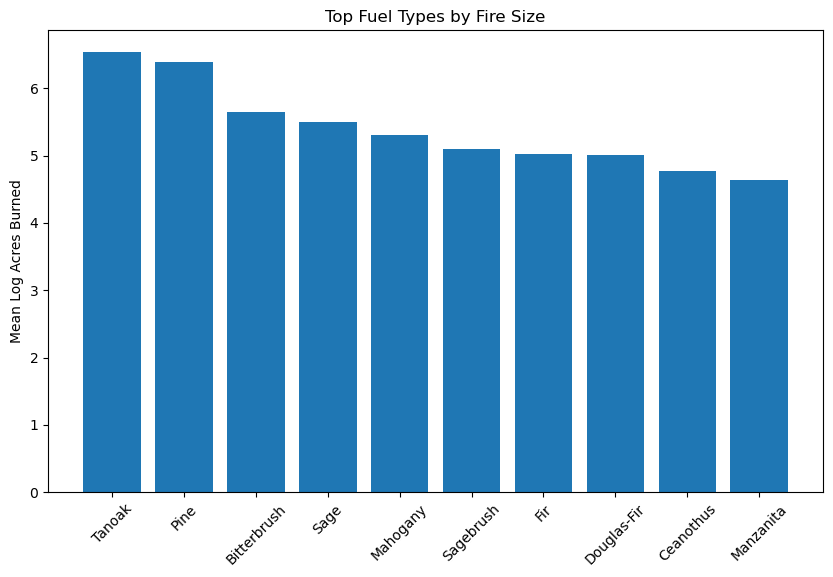

In [48]:
result["log_acres_burned"] = np.log1p(
    result["incident_acres_burned"]
)


fuel_summary = (
    result.groupby("FUEL_TYPE")
    .agg(
        fire_count=("incident_name", "count"),
        mean_acres=("incident_acres_burned", "mean"),
        median_acres=("incident_acres_burned", "median"),
        mean_log_acres=("log_acres_burned", "mean")
    )
    .sort_values("mean_log_acres", ascending=False)
)

fuel_summary.head(20)

top_fuels = fuel_summary.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_fuels.index,
    top_fuels["mean_log_acres"]
)

plt.xticks(rotation=45)
plt.ylabel("Mean Log Acres Burned")
plt.title("Top Fuel Types by Fire Size")

plt.show()

In [49]:
group_summary = (
    result.groupby("GROUP")
    .agg(
        fire_count=("incident_name", "count"),
        mean_log_acres=("log_acres_burned", "mean")
    )
    .sort_values("mean_log_acres", ascending=False)
)

group_summary.head(20)

,fire_count,mean_log_acres
GROUP,,
Lake Tahoe Basin M.U.,5,7.471741
Inyo NF,7,6.793628
Shasta-Trinity NF,20,6.738445
Plumas NF,11,5.980780
Klamath NF,61,5.962517
Orange County Fire,22,5.813686
Los Padres NF,60,5.742026
Angeles NF,32,5.695030
Kern County FD,43,5.523671


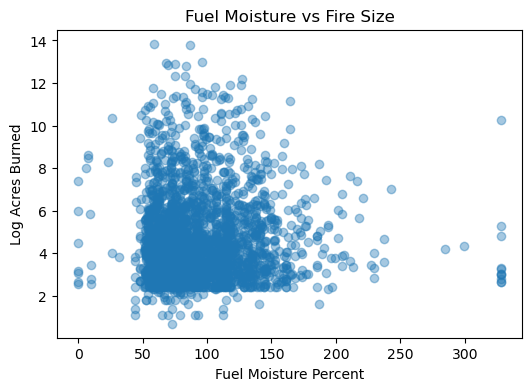

In [53]:
result["PERCENT"] = pd.to_numeric(
    result["PERCENT"],
    errors="coerce"
)

result[["PERCENT", "log_acres_burned"]].corr()

plt.figure(figsize=(6,4))

plt.scatter(
    result["PERCENT"],
    result["log_acres_burned"],
    alpha=0.4
)

plt.xlabel("Fuel Moisture Percent")
plt.ylabel("Log Acres Burned")
plt.title("Fuel Moisture vs Fire Size")

plt.show()

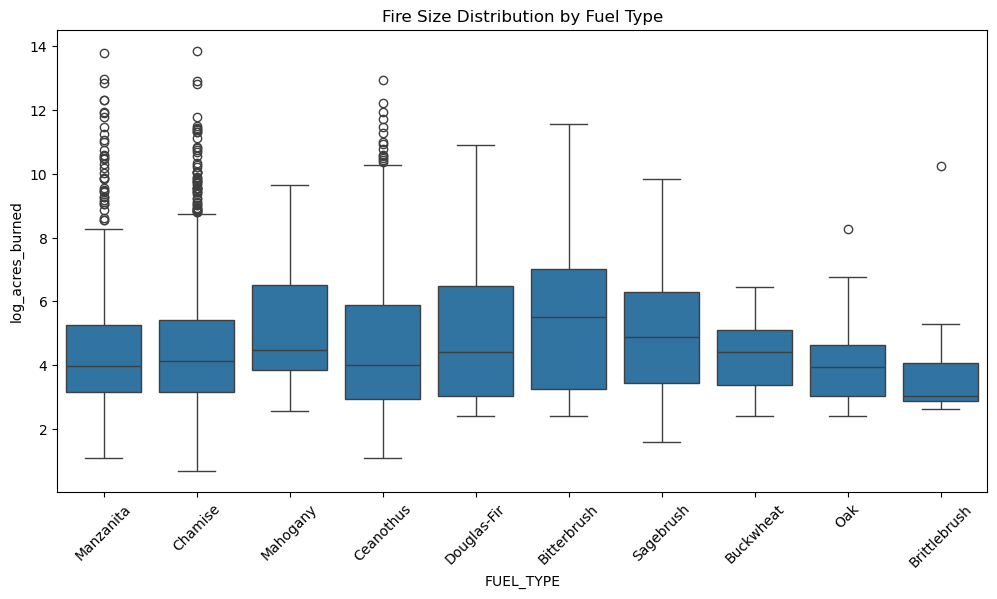

In [56]:
top_fuel_names = (
    result["FUEL_TYPE"]
    .value_counts()
    .head(10)
    .index
)

plot_df = result[
    result["FUEL_TYPE"].isin(top_fuel_names)
]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=plot_df,
    x="FUEL_TYPE",
    y="log_acres_burned"
)

plt.xticks(rotation=45)
plt.title("Fire Size Distribution by Fuel Type")

plt.show()